MERGING 2015-2020 DATa

In [3]:
import pandas as pd
import glob
import os
import re

In [ ]:
path = './'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Filter for files between 2015 and 2020 only
batch_files = [f for f in all_files if re.search(r'20(1[5-9]|20)-q', f)]

print(f"Found {len(batch_files)} files for the 2015-2020 period.")

# 2. Define the reading function for this specific batch
def read_2015_2020_format(file_path):
    # Based on your screenshot, this batch uses commas (,)
    # and has some quoting. we use dtype=str to avoid RUC corruption.
    df = pd.read_csv(
        file_path,
        sep=',',
        encoding='utf-8',
        quotechar='"',
        dtype=str,
        low_memory=False
    )

    # Standardize headers: Remove quotes, strip spaces, uppercase
    df.columns = df.columns.str.replace('"', '').str.strip().str.upper()

    # Track the source for debugging
    df['ORIGIN_QUARTER'] = os.path.basename(file_path)
    return df

# 3. Execution Loop
li = []
for filename in sorted(batch_files):
    print(f"Reading: {filename}...")
    df = read_2015_2020_format(filename)
    li.append(df)

# Concatenate into one master dataframe
df_15_20 = pd.concat(li, axis=0, ignore_index=True)

# 4. Final Cleanup
# Convert the 'US$ FOB' column to numeric so you can do math for your segmentation
if 'US$ FOB' in df_15_20.columns:
    df_15_20['US$ FOB'] = pd.to_numeric(df_15_20['US$ FOB'], errors='coerce')

print("---")
print(f"Unification complete. Total rows: {len(df_15_20):,}")
print(df_15_20.info())

Found 24 files for the 2015-2020 period.
Reading: ./2015-q1.csv...
Reading: ./2015-q2.csv...
Reading: ./2015-q3.csv...
Reading: ./2015-q4.csv...
Reading: ./2016-q1.csv...
Reading: ./2016-q2.csv...
Reading: ./2016-q3.csv...
Reading: ./2016-q4.csv...
Reading: ./2017-q1.csv...
Reading: ./2017-q2.csv...
Reading: ./2017-q3.csv...
Reading: ./2017-q4.csv...
Reading: ./2018-q1.csv...
Reading: ./2018-q2.csv...
Reading: ./2018-q3.csv...
Reading: ./2018-q4.csv...
Reading: ./2019-q1.csv...
Reading: ./2019-q2.csv...
Reading: ./2019-q3.csv...
Reading: ./2019-q4.csv...
Reading: ./2020-q1.csv...
Reading: ./2020-q2.csv...
Reading: ./2020-q3.csv...
Reading: ./2020-q4.csv...
---
Unification complete. Total rows: 366,358
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366358 entries, 0 to 366357
Data columns (total 65 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   DIA                         366358 non-null  object 
 1  

In [ ]:
df_15_20.to_pickle("imports_2015_2020.pkl") 

MERGING 2021-2026 DATA

In [ ]:
import pandas as pd
import os

# files for the 2021-2026 batch
datasur_files = [
    'datasur-21-22.csv',
    'datasur-23-24.csv',
    'datasur-25-26.csv'
]

def read_datasur_format(file_path):
    print(f"Reading {file_path}...")

    # semicolon separator, unlike the previous batch which used commas
    # quotechar='"' handles the first layer of quotes
    df = pd.read_csv(
        file_path,
        sep=';',
        encoding='utf-8',
        dtype=str,
        quotechar='"'
    )

    # remove the second layer of quotes and whitespace
    df.columns = [col.replace('"', '').strip().upper() for col in df.columns]

    # remove the second layer of quotes from all values
    # vectorized string replace for speed
    for col in df.columns:
        df[col] = df[col].str.replace('"', '', regex=False).str.strip()

    # standardize 'ANO' to 'AÑO' to match the 2015-2020 batch
    if 'ANO' in df.columns:
        df.rename(columns={'ANO': 'AÑO'}, inplace=True)

    df['SOURCE_BATCH'] = '2021-2026'
    return df

# 4. process and Unify
li_datasur = []
for f in datasur_files:
    if os.path.exists(f):
        df_temp = read_datasur_format(f)
        li_datasur.append(df_temp)
    else:
        print(f"Warning: {f} not found in current directory.")

df_21_26 = pd.concat(li_datasur, axis=0, ignore_index=True)

# 5. save as Pickle
df_21_26.to_pickle("imports_2021_2026.pkl")

print("---")
print(f"Success! Processed {len(df_21_26):,} rows.")
print(f"Columns found: {list(df_21_26.columns)}")

Reading datasur-21-22.csv...
Reading datasur-23-24.csv...
Reading datasur-25-26.csv...
---
Success! Processed 71,224 rows.
Columns found: ['DÍA', 'MES', 'AÑO', 'DUA', 'SERIE', 'ADUANA', 'TIPO DOCUMENTO', 'RUC IMPORTADOR', 'IMPORTADOR', 'DIRECCIÓN', 'TELÉFONO', 'FAX', 'DEPARTAMENTO DE IMPORTADOR', 'PROVINCIA', 'DISTRITO', 'VÍA DE TRANSPORTE', 'BANCO', 'PAÍS DE ORIGEN', 'PAÍS DE ADQUISICIÓN', 'PUERTO DE EMBARQUE', 'PARTIDA ARANCELARIA', 'DESCRIPCIÓN ARANCELARIA', 'MERCANCÍA', 'DESCRIPCIÓN DE MERCANCÍA 1', 'DESCRIPCIÓN DE MERCANCÍA 2', 'DESCRIPCIÓN DE MERCANCÍA 3', 'DESCRIPCIÓN DE MERCANCÍA 4', 'PRODUCTO', 'MARCA', 'MODELO', 'CARACTERÍSTICAS', 'AÑO FABRICACIÓN', 'US$ FOB', 'US$ FLETE', 'US$ SEGURO', 'US$ CIF', 'ADVALOREM', 'IGV', 'IPM', 'PESO NETO', 'PESO BRUTO', 'CANTIDAD', 'UNIDAD DE MEDIDA', 'US$ CIF UNIT', 'CANTIDAD COMERCIAL', 'UNIDAD COMERCIAL', 'TIPO DE BULTO', 'CANTIDAD BULTO', 'ESTADO DE MERCANCIA', 'PROBABLE EMBARCADOR', 'AGENTE DE ADUANA', 'EMPRESA DE TRANSPORTE', 'ALMACEN', 'I

UNIFYING DATASETS

In [45]:
# Load both cleaned pickles and merge
df1 = pd.read_pickle("imports_2015_2020.pkl")
df2 = pd.read_pickle("imports_2021_2026.pkl")

huge_dataset = pd.concat([df1, df2], axis=0, ignore_index=True)
print(f"Merged dataset: {len(huge_dataset):,} rows, {len(huge_dataset.columns)} columns")


Merged dataset: 437,582 rows, 77 columns


Checking data consistency

### Checking column alignment between both batches

In [46]:
cols1 = set(df1.columns)
cols2 = set(df2.columns)

shared     = cols1.intersection(cols2)
only_15_20 = cols1 - cols2
only_21_26 = cols2 - cols1

print(f"--- Shared Columns ({len(shared)}) ---")
print(sorted(list(shared)))
print(f"\n--- Columns ONLY in 2015-2020 ({len(only_15_20)}) ---")
print(sorted(list(only_15_20)))
print(f"\n--- Columns ONLY in 2021-2026 ({len(only_21_26)}) ---")
print(sorted(list(only_21_26)))


--- Shared Columns (53) ---
['ADUANA', 'ADVALOREM', 'AGENTE DE ADUANA', 'AGENTE DE CARGA EN DESTINO', 'ALMACEN', 'AÑO', 'AÑO FABRICACIÓN', 'BANCO', 'BILL OF LADING', 'BILL OF LADING MASTER', 'BUQUE', 'CANTIDAD', 'CANTIDAD BULTO', 'CANTIDAD COMERCIAL', 'DEPARTAMENTO DE IMPORTADOR', 'DESCRIPCIÓN DE MERCANCÍA 1', 'DESCRIPCIÓN DE MERCANCÍA 2', 'DESCRIPCIÓN DE MERCANCÍA 3', 'DESCRIPCIÓN DE MERCANCÍA 4', 'DISTRITO', 'DUA', 'EMPRESA DE TRANSPORTE', 'ESTADO DE MERCANCIA', 'FAX', 'FECHA DE EMBARQUE', 'FECHA DE LLEGADA', 'FORMA DE PAGO', 'IGV', 'IMPORTADOR', 'INCOTERM', 'IPM', 'MANIFIESTO DE CARGA', 'MARCA', 'MERCANCÍA', 'MES', 'MODELO', 'PARTIDA ARANCELARIA', 'PESO BRUTO', 'PESO NETO', 'PRODUCTO', 'PUERTO DE EMBARQUE', 'RUC IMPORTADOR', 'SERIE', 'TIPO DE BULTO', 'TIPO DOCUMENTO', 'UNIDAD COMERCIAL', 'UNIDAD DE MEDIDA', 'US$ CIF', 'US$ CIF UNIT', 'US$ FLETE', 'US$ FOB', 'US$ FOB UNIT', 'US$ SEGURO']

--- Columns ONLY in 2015-2020 (12) ---
['CANTIDAD DE BULTOS', 'CARACTERISTICAS', 'DESCRIPCION AR

THERE IS STILL A PROBLEM WITH ACCENTS AND PUNCTUATION HEHE. NOW TRYING TO SOLVE THAT

In [47]:
import unicodedata

def clean_column_names(df):
    """
    Removes accents, replaces spaces with underscores,
    and forces uppercase for perfect alignment.
    Ensures column names are unique after cleaning.
    """
    new_cols = []
    existing_cleaned_names = set()
    for col in df.columns:
        # 1. Normalize unicode characters (turns Á into A) #
        # Using errors='ignore' because some characters might not be ASCII mappable
        n = unicodedata.normalize('NFKD', col).encode('ASCII', 'ignore').decode('utf-8')
        # 2. Cleanup: Uppercase, remove double spaces, strip
        n = n.upper().strip()
        # 3. Manual fix for specific mismatches you found
        if n == 'CANTIDAD DE BULTOS': n = 'CANTIDAD BULTO'
        if n == 'EMBARCADOR': n = 'PROBABLE EMBARCADOR'


        # Ensure uniqueness by appending a number if duplicate is found
        original_n = n
        count = 1
        while n in existing_cleaned_names:
            n = f"{original_n}_{count}"
            count += 1
        new_cols.append(n)
        existing_cleaned_names.add(n) # Add the unique name to the set

    df.columns = new_cols
    return df


# Apply the 'Nuke' cleaner to both
df1 = clean_column_names(df1)
df2 = clean_column_names(df2)

# 3. Now merge them
huge_dataset = pd.concat([df1, df2], axis=0, ignore_index=True)

# 4. Check the results
print(f"New column count: {len(huge_dataset.columns)}")
print("Commonly broken columns are now unified:")
print([c for c in huge_dataset.columns if 'PAIS' in c or 'VIA' in c])

New column count: 68
Commonly broken columns are now unified:
['VIA DE TRANSPORTE', 'PAIS DE ORIGEN', 'PAIS DE ADQUISICION']


In [48]:
huge_dataset.isnull().mean().sort_values(ascending=False).head(30) #Ok. it seems there are still some empty columns. I will remove some more...
# I will need to clean up some parts, still...

CANAL                         0.961299
PROVINCIA                     0.881910
SOURCE_BATCH                  0.837233
AGENTE DE CARGA EN DESTINO    0.808372
ANO FABRICACION               0.752152
CANTIDAD BULTO_1              0.735858
BUQUE                         0.728515
BILL OF LADING MASTER         0.645001
FORMA DE PAGO                 0.609783
FECHA DE EMBARQUE             0.602630
BILL OF LADING                0.602630
CANTIDAD BULTO                0.264145
ESTADO                        0.260733
DESCRIPCION DE MERCANCIA 1    0.248673
BANCO                         0.172969
ORIGIN_QUARTER                0.162767
TELEFONO                      0.139023
DISTRITO                      0.138769
DEPARTAMENTO DE IMPORTADOR    0.138769
FAX                           0.138401
DIRECCION                     0.138399
ALMACEN                       0.133525
DESCRIPCION DE MERCANCIA 4    0.122667
PROBABLE EMBARCADOR           0.082711
DESCRIPCION DE MERCANCIA 2    0.074260
EMPRESA DE TRANSPORTE    

### Unifying and cleaning columns

In [49]:
import numpy as np

# 1. Replace placeholder strings with actual NaN
# We use a list of common "dirty" placeholders found in SUNAT/Datasur data
dirty_placeholders = ['-', ':::', '.', 'nan', 'N/A', ' ', '']

print("Replacing placeholders with NaN...")
huge_dataset = huge_dataset.replace(dirty_placeholders, np.nan)

# 2. Fix the "CANTIDAD BULTO_1" duplication
# This happens if one column had a hidden character or space.
if 'CANTIDAD BULTO_1' in huge_dataset.columns:
    print("Consolidating duplicated Bulto columns...")
    huge_dataset['CANTIDAD BULTO'] = huge_dataset['CANTIDAD BULTO'].fillna(huge_dataset['CANTIDAD BULTO_1'])
    huge_dataset = huge_dataset.drop(columns=['CANTIDAD BULTO_1'])

# 3. Consolidate PROVINCIA and ESTADO
# In Peru, these are often the same field depending on the year
if 'PROVINCIA' in huge_dataset.columns and 'ESTADO' in huge_dataset.columns:
    print("Merging Provincia and Estado...")
    huge_dataset['UBIGEO_REGION'] = huge_dataset['PROVINCIA'].fillna(huge_dataset['ESTADO'])

# 4. Drop rows without an importer identifier
huge_dataset = huge_dataset.dropna(subset=['RUC IMPORTADOR'])

print("--- Cleaned Dataset Stats ---")
print(f"Total Rows: {len(huge_dataset):,}")
print(f"Total Columns: {len(huge_dataset.columns)}")

Replacing placeholders with NaN...
Consolidating duplicated Bulto columns...
Merging Provincia and Estado...
--- Cleaned Dataset Stats ---
Total Rows: 437,582
Total Columns: 68


In [50]:
# Fix the names based on RUC
name_fix = huge_dataset.groupby('RUC IMPORTADOR')['IMPORTADOR'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
huge_dataset['IMPORTADOR'] = huge_dataset['RUC IMPORTADOR'].map(name_fix)

# Quick check on scania. It seems to be fine
print(huge_dataset[huge_dataset['IMPORTADOR'].str.contains('SCANIA', na=False)]['IMPORTADOR'].unique()) 

<StringArray>
['SCANIA DEL PERU S A']
Length: 1, dtype: str


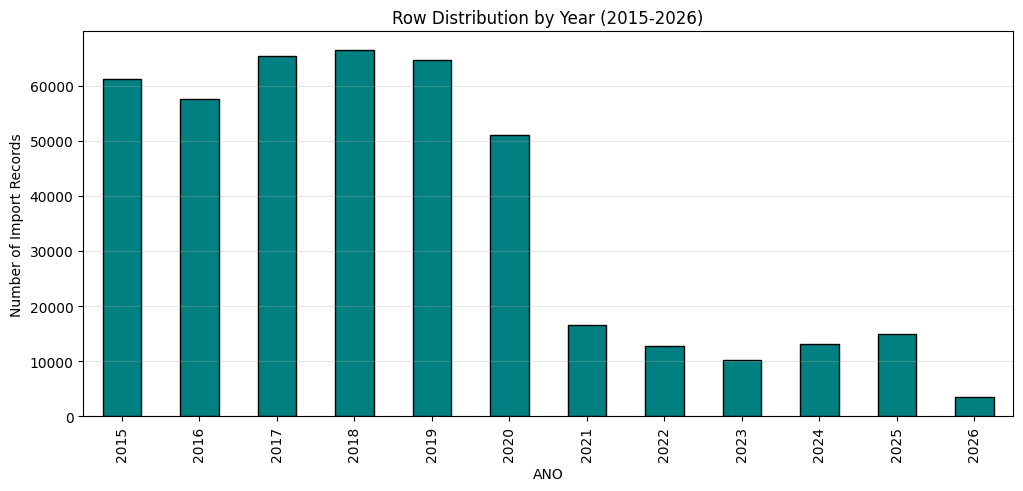

Yearly counts:
 ANO
2015    61279
2016    57605
2017    65380
2018    66510
2019    64598
2020    50986
2021    16682
2022    12696
2023    10216
2024    13136
2025    14951
2026     3543
Name: count, dtype: int64


In [51]:
import matplotlib.pyplot as plt 

# Count rows per year
yearly_stats = huge_dataset['ANO'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
yearly_stats.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Row Distribution by Year (2015-2026)')
plt.ylabel('Number of Import Records')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Yearly counts:\n", yearly_stats) # super uneven distribution. several 'useless' entries/goods for my analysis. might be due to the insane amount of accesories inlcuded in the hs codes

Checking which hs code belongs to which period

In [52]:
# standardize the column first (if not already done)
huge_dataset['PARTIDA_CLEAN'] = huge_dataset['PARTIDA ARANCELARIA'].astype(str).str.replace(r'\D', '', regex=True)

# separate the sets of codes
codes_old = set(huge_dataset[huge_dataset['ANO'].astype(int) <= 2020]['PARTIDA_CLEAN'].unique())
codes_new = set(huge_dataset[huge_dataset['ANO'].astype(int) >= 2021]['PARTIDA_CLEAN'].unique())

# calculate intersections
common_codes = codes_old.intersection(codes_new)
only_in_old = codes_old - codes_new
only_in_new = codes_new - codes_old

print(f"--- HS CODE SUMMARY ---")
print(f"Codes in both periods: {len(common_codes)}")
print(f"Codes ONLY in 2015-2020: {len(only_in_old)}  <-- The 'Pollution'")
print(f"Codes ONLY in 2021-2026: {len(only_in_new)}")

if len(only_in_old) > 0:
    print(f"\nSample of 'Polluted' codes (Top 5): {list(only_in_old)[:5]}")
    # calculate the number of entries with these polluting HS codes
    polluting_entries = huge_dataset[huge_dataset['PARTIDA_CLEAN'].isin(only_in_old)]
    print(f"Number of entries with 'Polluting' HS codes: {len(polluting_entries):,}")

--- HS CODE SUMMARY ---
Codes in both periods: 12
Codes ONLY in 2015-2020: 2  <-- The 'Pollution'
Codes ONLY in 2021-2026: 1

Sample of 'Polluted' codes (Top 5): ['8474203000', '8431490000']
Number of entries with 'Polluting' HS codes: 289,196


In [53]:
# calculate percentage of missing values per column
missing_pct = (huge_dataset.isnull().sum() / len(huge_dataset)) * 100

print("--- MISSING DATA PER COLUMN (%) ---")
print(missing_pct.sort_values(ascending=False).head(10)) # Already check which one to remove

--- MISSING DATA PER COLUMN (%) ---
FAX                           99.998629
ANO FABRICACION               98.504280
CANAL                         96.129868
PROVINCIA                     88.191013
SOURCE_BATCH                  83.723279
AGENTE DE CARGA EN DESTINO    80.837192
BUQUE                         72.851488
BILL OF LADING MASTER         64.500139
FORMA DE PAGO                 60.978285
FECHA DE EMBARQUE             60.262991
dtype: float64


In [54]:
# Define threshold (e.g., keep columns with at least 10% data)
limit = len(huge_dataset) * 0.10
huge_dataset_final = huge_dataset.dropna(axis=1, thresh=limit)

# manually dropping 'noise' columns (even if they have data, they don't help segment)
noise_cols = ['FAX', 'TIPO DOCUMENTO','TELEFONO', 'SOURCE_BATCH', 'ORIGIN_QUARTER',
              'US$ FLETE', 'US$ SEGURO', 'CARACTERISTICAS', 'IGV', 'IPM', 'PESO BRUTO', 'CANTIDAD COMERCIAL',
              'UNIDAD COMERCIAL', 'ADVALOREM', 'PESO NETO', 'UNIDAD DE MEDIDA','DESCRIPCION DE MERCANCIA 4', 'ADUANA', 'PUERTO DE EMBARQUE', 'EMPRESA DE TRANSPORTE',
              'ALMACEN','FORMA DE PAGO', 'AGENTE DE CARGA EN DESTINO', 'TIPO DE BULTO', 'CANTIDAD BULTO', 'DUA', 'SERIE', 'BANCO',
              'MANIFIESTO DE CARGA','AGENTE DE ADUANA','VIA DE TRANSPORTE', 'INCOTERM', 'BILL OF LADING MASTER', 'BILL OF LADING', 'BUQUE']
huge_dataset_final = huge_dataset_final.drop(columns=[c for c in noise_cols if c in huge_dataset_final.columns])

print(f"Columns removed. Remaining columns: {len(huge_dataset_final.columns)}")

Columns removed. Remaining columns: 32


In [55]:
# Rename UBIGEO_REGION → REGION_UNIFIED for downstream consistency
if 'UBIGEO_REGION' in huge_dataset_final.columns:
    huge_dataset_final = huge_dataset_final.rename(columns={'UBIGEO_REGION': 'REGION_UNIFIED'})

print("Available columns:")
print(list(huge_dataset_final.columns))


Available columns:
['DIA', 'MES', 'ANO', 'RUC IMPORTADOR', 'IMPORTADOR', 'DIRECCION', 'DEPARTAMENTO DE IMPORTADOR', 'ESTADO', 'DISTRITO', 'PAIS DE ORIGEN', 'PAIS DE ADQUISICION', 'PARTIDA ARANCELARIA', 'DESCRIPCION ARANCELARIA', 'MERCANCIA', 'DESCRIPCION DE MERCANCIA 1', 'DESCRIPCION DE MERCANCIA 2', 'DESCRIPCION DE MERCANCIA 3', 'PRODUCTO', 'MARCA', 'MODELO', 'US$ FOB', 'US$ CIF', 'CANTIDAD', 'US$ CIF UNIT', 'ESTADO DE MERCANCIA', 'PROBABLE EMBARCADOR', 'FECHA DE LLEGADA', 'US$ FOB UNIT', 'FECHA DE EMBARQUE', 'PROVINCIA', 'REGION_UNIFIED', 'PARTIDA_CLEAN']


In [56]:
# Fill remaining text columns with "UNKNOWN" (leaves NaN in numeric columns intact)
str_cols = huge_dataset_final.select_dtypes(include='object').columns
huge_dataset_final[str_cols] = huge_dataset_final[str_cols].fillna("UNKNOWN")

# Convert money columns to numeric — NaN stays NaN, never fill with 0
for _col in ['US$ FOB', 'US$ CIF', 'US$ FOB UNIT', 'US$ CIF UNIT']:
    if _col in huge_dataset_final.columns:
        huge_dataset_final[_col] = pd.to_numeric(huge_dataset_final[_col], errors='coerce')

print(f"Rows with valid FOB:   {huge_dataset_final['US$ FOB'].notna().sum():,}")
print(f"Rows with missing FOB: {huge_dataset_final['US$ FOB'].isna().sum():,}")


/var/folders/bg/ymwvmw894xsg930tx_lwtysw0000gn/T/ipykernel_87379/1315949652.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = huge_dataset_final.select_dtypes(include='object').columns


Rows with valid FOB:   437,581
Rows with missing FOB: 1


In [57]:
# ── Recover UNKNOWN 'DEPARTAMENTO DE IMPORTADOR' ─────────────────────────────
# The source data (SUNAT/Datasur) is missing department for ~17% of rows.
# Three strategies applied in priority order:
#   1. RUC lookup   — same company appears with a known dept in other transactions
#   2. Name keyword — dept name embedded in company name (e.g. "EMPRESA LIMA S.A.C.")
#   3. Address text — dept name found in DIRECCION field
# Remaining unknowns are genuine data gaps and kept as UNKNOWN.
import re

_dept_col = 'DEPARTAMENTO DE IMPORTADOR'
_unk_mask  = huge_dataset_final[_dept_col].str.upper().str.strip() == 'UNKNOWN'
_n_before  = _unk_mask.sum()

# ── Strategy 1: RUC lookup from known transactions ───────────────────────────
_ruc_dept = (
    huge_dataset_final[~_unk_mask]
    .groupby('RUC IMPORTADOR')[_dept_col]
    .agg(lambda x: x.value_counts().index[0])
)
_s1 = _unk_mask & huge_dataset_final['RUC IMPORTADOR'].isin(_ruc_dept.index)
huge_dataset_final.loc[_s1, _dept_col] = (
    huge_dataset_final.loc[_s1, 'RUC IMPORTADOR'].map(_ruc_dept)
)
_unk_mask = huge_dataset_final[_dept_col].str.upper().str.strip() == 'UNKNOWN'
_n_s1 = _n_before - _unk_mask.sum()

# ── Strategy 2 & 3: keyword scan on company name + address ───────────────────
_DEPT_KEYWORDS = {
    'LIMA':                    r'\bLIMA\b',
    'AREQUIPA':                r'\bAREQUIPA\b',
    'CUSCO':                   r'\bCUSCO\b',
    'PUNO':                    r'\bPUNO\b',
    'LA LIBERTAD':             r'\bLA LIBERTAD\b|\bTRUJILLO\b',
    'LORETO':                  r'\bLORETO\b|\bIQUITOS\b',
    'PROV. CONST. DEL CALLAO': r'\bCALLAO\b',
    'ANCASH':                  r'\bANCAHSH\b|\bHUARAZ\b',
    'LAMBAYEQUE':              r'\bLAMBAYEQUE\b|\bCHICLAYO\b',
    'PIURA':                   r'\bPIURA\b',
    'CAJAMARCA':               r'\bCAJAMARCA\b',
    'JUNIN':                   r'\bJUNIN\b|\bHUANCAYO\b',
    'TACNA':                   r'\bTACNA\b',
    'UCAYALI':                 r'\bUCAYALI\b|\bPUCALLPA\b',
    'ICA':                     r'\bICA\b',
    'MOQUEGUA':                r'\bMOQUEGUA\b',
    'SAN MARTIN':              r'\bSAN MARTIN\b|\bTARAPOTO\b',
    'AMAZONAS':                r'\bAMAZONAS\b|\bCHACHAPOYAS\b',
    'APURIMAC':                r'\bAPURIMAC\b|\bABANCAY\b',
    'AYACUCHO':                r'\bAYACUCHO\b',
    'HUANCAVELICA':            r'\bHUANCAVELICA\b',
    'HUANUCO':                 r'\bHUANUCO\b',
    'MADRE DE DIOS':           r'\bMADRE DE DIOS\b|\bPUERTO MALDONADO\b',
    'PASCO':                   r'\bPASCO\b|\bCERRO DE PASCO\b',
    'TUMBES':                  r'\bTUMBES\b',
}

_n_s2 = 0
for _source_col in ['IMPORTADOR', 'DIRECCION']:
    if _source_col not in huge_dataset_final.columns:
        continue
    _text = huge_dataset_final[_source_col].fillna('').str.upper()
    for _dept, _pat in _DEPT_KEYWORDS.items():
        _hit = _unk_mask & _text.str.contains(_pat, regex=True, na=False)
        if _hit.any():
            huge_dataset_final.loc[_hit, _dept_col] = _dept
            _n_s2 += _hit.sum()
            _unk_mask = huge_dataset_final[_dept_col].str.upper().str.strip() == 'UNKNOWN'

_n_after = _unk_mask.sum()
print(f"DEPARTAMENTO DE IMPORTADOR recovery")
print(f"  Before      : {_n_before:>6,} UNKNOWN  ({_n_before/len(huge_dataset_final)*100:.1f}%)")
print(f"  Strategy 1  : {_n_s1:>6,} recovered via RUC lookup")
print(f"  Strategy 2/3: {_n_s2:>6,} recovered via name/address keywords")
print(f"  After       : {_n_after:>6,} UNKNOWN  ({_n_after/len(huge_dataset_final)*100:.1f}%)")
print(f"  Unresolvable: {_n_after:>6,} rows — genuine data gap in source")


DEPARTAMENTO DE IMPORTADOR recovery
  Before      : 60,723 UNKNOWN  (13.9%)
  Strategy 1  :  6,561 recovered via RUC lookup
  Strategy 2/3:  1,598 recovered via name/address keywords
  After       : 52,564 UNKNOWN  (12.0%)
  Unresolvable: 52,564 rows — genuine data gap in source


In [58]:
# Get unique RUCs from both eras
rucs_old = set(huge_dataset_final[huge_dataset_final['ANO'].astype(int) <= 2020]['RUC IMPORTADOR'].unique())
rucs_new = set(huge_dataset_final[huge_dataset_final['ANO'].astype(int) >= 2021]['RUC IMPORTADOR'].unique())

survivors = rucs_old.intersection(rucs_new)

print(f"--- IMPORTER CONTINUITY ---")
print(f"Unique Importers (2015-2020): {len(rucs_old)}")
print(f"Unique Importers (2021-2026): {len(rucs_new)}")
print(f"Importers present in BOTH periods: {len(survivors)}") # There seems to be a constant increase of new importers woww

--- IMPORTER CONTINUITY ---
Unique Importers (2015-2020): 3174
Unique Importers (2021-2026): 3182
Importers present in BOTH periods: 858


In [59]:
columns_to_merge = ['DESCRIPCION DE MERCANCIA 1', 'DESCRIPCION DE MERCANCIA 2', 'DESCRIPCION DE MERCANCIA 3'] # some of the product brand and model are also found on the complementary descriptions. I'll use them because there are many 'UNKNOWN' entries.

# Replace 'UNKNOWN' with NaN so it's treated as a missing value and ignored during join
huge_dataset_final[columns_to_merge] = huge_dataset_final[columns_to_merge].replace('UNKNOWN', pd.NA)

huge_dataset_final['DESCRIPTION_MERGED'] = huge_dataset_final[columns_to_merge].fillna('').agg(' '.join, axis=1)

# Clean up any multiple spaces that might result from concatenating empty strings
huge_dataset_final['DESCRIPTION_MERGED'] = huge_dataset_final['DESCRIPTION_MERGED'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(huge_dataset_final[['DESCRIPTION_MERGED', 'DESCRIPCION DE MERCANCIA 1', 'DESCRIPCION DE MERCANCIA 2', 'DESCRIPCION DE MERCANCIA 3']].head())

                                  DESCRIPTION_MERGED  \
0  VOE 12744293 REPUESTOS PARA MAQUINARIA PESADA ...   
1  NC:6,CC:11596,VI:LZGJLN840FG000007,MO:1414S063...   
2                                    REPUESTO UNIDAD   
3                                    REPUESTO UNIDAD   
4                                    COMERCIAL BULTO   

                          DESCRIPCION DE MERCANCIA 1  \
0                                       VOE 12744293   
1  NC:6,CC:11596,VI:LZGJLN840FG000007,MO:1414S063...   
2                                               <NA>   
3                                               <NA>   
4                                               <NA>   

                          DESCRIPCION DE MERCANCIA 2  \
0                   REPUESTOS PARA MAQUINARIA PESADA   
1  AS:2,EJ:3,FR:6X4,TT:MECANICO,PA:1,PM:283@2200,...   
2                                           REPUESTO   
3                                           REPUESTO   
4                                          COM

In [60]:
# ── MARCA / MODELO enrichment & standardisation ──────────────────────────────
# Runs on the full dataset AFTER DESCRIPTION_MERGED is built and BEFORE
# MARCA_CLEAN is derived, so every downstream notebook benefits automatically.
#
# Three steps:
#   1. Canonical map  — prefix noise (M/VOLVO, MARCA:CAT) + hard typos
#   2. Fuzzy matching — remaining typos caught at ≥82% similarity
#   3. Excel lookup   — fill UNKNOWN MARCA/MODELO from DESCRIPTION_MERGED
#      using make-model-cptrucks.xlsx as the CPtrucks reference dictionary
import re
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz

# ── 1. Canonical correction map ───────────────────────────────────────────────
_CANON = {
    'CAT': 'CATERPILLAR', 'CAT CATERPILLAR': 'CATERPILLAR',
    'CAT / CATERPILLAR': 'CATERPILLAR', 'CAT(CATERPILLAR)': 'CATERPILLAR',
    'CATERPILLAR (CAT)': 'CATERPILLAR', 'CATERPILLAR INC': 'CATERPILLAR',
    'CATERPILLAR(CAT)': 'CATERPILLAR',
    'M/CATERPILLAR': 'CATERPILLAR', 'M/.CATERPILLAR': 'CATERPILLAR',
    'M: CATERPILLAR': 'CATERPILLAR', 'M:/CATERPILLAR': 'CATERPILLAR',
    'M:CATERPILLAR': 'CATERPILLAR', 'MARCA: CATERPILLAR': 'CATERPILLAR',
    'MARCA:CATERPILLAR': 'CATERPILLAR',
    'VOL': 'VOLVO', 'VOLVO BM': 'VOLVO', 'VOLVO PM AB': 'VOLVO',
    'M/VOLVO': 'VOLVO', 'M/VOLVO BM': 'VOLVO', 'M:VOLVO': 'VOLVO',
    'MARCA :VOLVO': 'VOLVO', 'MARCA: VOLVO': 'VOLVO', 'MARCA:VOLVO': 'VOLVO',
    'M:KOMATSU': 'KOMATSU', 'MOKATSU': 'KOMATSU',
    'JHON DEERE': 'JOHN DEERE', 'JOHN DEERE 320D': 'JOHN DEERE', 'DEERE': 'JOHN DEERE',
    'BOB CAT': 'BOBCAT', 'BOTBCAT': 'BOBCAT',
    'INGERSOL RAND': 'INGERSOLL RAND', 'INGERSOLL-RAND': 'INGERSOLL RAND',
    'INGRESOLL-RAND': 'INGERSOLL RAND',
    'DOSSAN': 'DOOSAN', 'DAEWOO DOOSAN': 'DOOSAN', 'DAEWOO-DOOSAN': 'DOOSAN',
    'DAEWO': 'DAEWOO',
    'MORGARD SHAMMAR': 'MORGARDSHAMMAR', 'MORGARDHAMMAR': 'MORGARDSHAMMAR',
    'MORGARDSHA MMAR': 'MORGARDSHAMMAR', 'MORGARSHAMAR': 'MORGARDSHAMMAR',
    'MOGARDSHAMMAR': 'MORGARDSHAMMAR',
    'SANDIVIK': 'SANDVIK', 'SANDVIC': 'SANDVIK', 'TAMROCK-SANVIK': 'SANDVIK',
    'ATLAS COPCO.': 'ATLAS COPCO', 'M/ATLAS COPCO': 'ATLAS COPCO',
    'LIUNGONG': 'LIUGONG', 'LIUGONG 856H': 'LIUGONG', 'LIUGONG LOADER': 'LIUGONG',
    'LINGONG': 'LIUGONG',
    'POWER SCREEN': 'POWERSCREEN', 'POWER SCREEN MACHINE': 'POWERSCREEN',
    'POWERSCREEM': 'POWERSCREEN',
    'MC CLOSKEY': 'MCCLOSKEY', 'MCKCLOSKEY': 'MCCLOSKEY',
    'MCCLOSKEY INTERNATIONAL': 'MCCLOSKEY',
    'HIUNDAY': 'HYUNDAI', 'HYUNDAI ROBEX': 'HYUNDAI',
    'VOEGELE': 'VOGELE',
    'SVEDLA': 'SVEDALA', 'SVEDAIA NO OPERATIVA': 'SVEDALA',
    'ALLIS CHALMER': 'ALLIS CHALMERS', 'ALLIS CHAMLMBERS': 'ALLIS CHALMERS',
    'KUE-KEN': 'KUE KEN', 'KUEKEN': 'KUE KEN',
    'CHANG LIN': 'CHANGLIN', 'TAI ZHONG': 'TAIZHONG',
    'FIAT-HITACHI': 'FIAT HITACHI', 'FIATALLIS': 'FIAT ALLIS',
    'TEREX-FINLAY': 'TEREX FINLAY', 'M:TEREX': 'TEREX',
    'METSO NORDBERG': 'METSO', 'NORDBERG-METSO': 'METSO',
    'METSO/NORDBERG': 'METSO', 'METSO LOKOMO': 'METSO',
    'KLEMM BOHRTECHENICK': 'KLEMM', 'KLEMM BOHRTECHNIK': 'KLEMM',
    'CHENILLES KLEMM': 'KLEMM', 'KLEEMAN': 'KLEEMANN',
    'M/SOILMEC': 'SOILMEC',
    # No-brand tokens
    'S/M': 'UNKNOWN', 'SIN MARCA': 'UNKNOWN', 'S/MARCA': 'UNKNOWN',
    '::::::': 'UNKNOWN', 'LOADER MACHINE': 'UNKNOWN', 'SHRERPILLAR': 'UNKNOWN',
}

_n_before = huge_dataset_final['MARCA'].str.upper().str.strip().nunique()
huge_dataset_final['MARCA'] = (
    huge_dataset_final['MARCA'].str.strip()
    .map(lambda v: _CANON.get(str(v).strip().upper(), str(v).strip()))
)

# ── 2. Fuzzy matching for remaining typos ─────────────────────────────────────
_CANONICAL_BRANDS = [
    'CATERPILLAR','VOLVO','KOMATSU','DOOSAN','DAEWOO','HYUNDAI','JOHN DEERE',
    'BOBCAT','CASE','HITACHI','LIEBHERR','SANDVIK','JCB','ATLAS COPCO','SANY',
    'XCMG','LIUGONG','SDLG','INGERSOLL RAND','DYNAPAC','HAMM','BOMAG','WIRTGEN',
    'ROADTEC','VOGELE','AMMANN','NEW HOLLAND','SAMSUNG','YANMAR','KUBOTA',
    'KOBELCO','TEREX','POWERSCREEN','MCCLOSKEY','METSO','SYMONS','NORDBERG',
    'MORGARDSHAMMAR','SVEDALA','BERGEAUD','CFBK','KRUPP','HAZEMAG','PEGSON',
    'CEDARAPIDS','TELSMITH','GOMACO','VERMEER','DITCH WITCH','MANITOU','MERLO',
    'GEHL','FIAT ALLIS','FIAT HITACHI','FIAT KOBELCO','WACKER NEUSON','EPIROC',
    'KLEMM','KLEEMANN','SOILMEC','ALLIS CHALMERS','CHAMPION','LEEBOY',
    'BERGKAMP','FINLAY','RESEMIN','NORMET','PUTZMEISTER','COMACCHIO',
    'CHANGLIN','TAIZHONG','KUE KEN',
]
_known_upper   = {b.upper() for b in _CANONICAL_BRANDS} | {'UNKNOWN'}
_brands_upper  = [b.upper() for b in _CANONICAL_BRANDS]
_needs_fuzzy   = huge_dataset_final['MARCA'][
    ~huge_dataset_final['MARCA'].str.upper().isin(_known_upper)
].unique()

_fuzzy_map = {}
for val in _needs_fuzzy:
    hit = process.extractOne(str(val).upper(), _brands_upper,
                             scorer=fuzz.token_sort_ratio, score_cutoff=82)
    if hit:
        _fuzzy_map[val] = next(b for b in _CANONICAL_BRANDS if b.upper() == hit[0])

huge_dataset_final['MARCA'] = huge_dataset_final['MARCA'].replace(_fuzzy_map)
_n_after = huge_dataset_final['MARCA'].str.upper().str.strip().nunique()
print(f"[1/2] MARCA standardised: {_n_before} → {_n_after} unique values "
      f"({_n_before - _n_after} variants collapsed, {len(_fuzzy_map)} fuzzy fixes)")

# ── 3. Excel lookup: fill UNKNOWN MARCA / MODELO from DESCRIPTION_MERGED ──────
_JUNK_MAKES  = {'BUCKET', 'CONTAINER', 'SPARE', 'SKID'}
_JUNK_MODELS = {'HAMMER','SPARE','PARTS','BLAUW','CONE','HOSE','III','NAN','NONE',''}

_ref = pd.read_excel('make-model-cptrucks.xlsx')
_make_models = {}
for _, row in _ref.iterrows():
    make  = str(row['make']).strip()
    model = str(row['model']).strip() if pd.notna(row['model']) else ''
    key   = make.upper()
    if key in _JUNK_MAKES:
        continue
    if key not in _make_models:
        _make_models[key] = {'canonical': make, 'models': set()}
    if model.upper() not in _JUNK_MODELS:
        _make_models[key]['models'].add(model)

_MODEL_REGEX = {
    'CATERPILLAR': [
        r'\bCAT0?([A-Z]{0,2}[0-9]{2,4}[A-Z]{0,2})\b',
        r'\b(IT[0-9]{2}[A-Z]?)\b',
        r'\b(140[A-Z][0-9]?)\b',
    ],
    'VOLVO': [r'\b([ELF][0-9]{2,3}[A-Z]{0,2})\b'],
    'GOMACO': [r'\b(GT[0-9]{4}|[0-9]{3,4})\b'],
}

# Vectorised: for each make, update UNKNOWN rows where DESC contains the make name
_desc_up    = huge_dataset_final['DESCRIPTION_MERGED'].fillna('').str.upper()
_marca_up   = huge_dataset_final['MARCA'].str.upper().str.strip()
_modelo_up  = huge_dataset_final['MODELO'].str.upper().str.strip()
_marca_unk  = _marca_up.isin({'UNKNOWN', '', 'NAN'})
_modelo_unk = _modelo_up.isin({'UNKNOWN', '', 'NAN'})

_sorted_makes = sorted(_make_models.keys(), key=len, reverse=True)
_marca_resolved = 0
_modelo_resolved = 0

for _key in _sorted_makes:
    _info       = _make_models[_key]
    _in_desc    = _desc_up.str.contains(r'\b' + re.escape(_key) + r'\b', regex=True, na=False)
    _fill_marca = _marca_unk & _in_desc & ~huge_dataset_final['MARCA'].str.upper().isin({_key})
    if _fill_marca.any():
        huge_dataset_final.loc[_fill_marca, 'MARCA'] = _info['canonical']
        _marca_resolved += _fill_marca.sum()
        _marca_unk = huge_dataset_final['MARCA'].str.upper().str.strip().isin({'UNKNOWN','','NAN'})

    # Model: dictionary pass
    for _model in _info['models']:
        _fill_mod = (_modelo_unk &
                     _in_desc &
                     _desc_up.str.contains(r'\b' + re.escape(_model.upper()) + r'\b',
                                           regex=True, na=False))
        if _fill_mod.any():
            huge_dataset_final.loc[_fill_mod, 'MODELO'] = _model
            _modelo_resolved += _fill_mod.sum()
            _modelo_unk = huge_dataset_final['MODELO'].str.upper().str.strip().isin({'UNKNOWN','','NAN'})

    # Model: regex pass for serial-number patterns
    _pats = _MODEL_REGEX.get(_key, [])
    if _pats:
        _still_unk_mod = _modelo_unk & _in_desc
        if _still_unk_mod.any():
            for _pat in _pats:
                _extracted = _desc_up[_still_unk_mod].str.extract(_pat, expand=False)
                _valid      = _extracted.notna()
                if _valid.any():
                    _idx = _still_unk_mod[_still_unk_mod].index[_valid]
                    huge_dataset_final.loc[_idx, 'MODELO'] = _extracted[_valid].values
                    _modelo_resolved += len(_idx)
                    _modelo_unk = huge_dataset_final['MODELO'].str.upper().str.strip().isin({'UNKNOWN','','NAN'})
                    _still_unk_mod = _modelo_unk & _in_desc

_m_unk_final  = huge_dataset_final['MARCA'].str.upper().str.strip().isin({'UNKNOWN','','NAN'}).sum()
_mo_unk_final = huge_dataset_final['MODELO'].str.upper().str.strip().isin({'UNKNOWN','','NAN'}).sum()
print(f"[2/2] Excel lookup:  MARCA filled {_marca_resolved} rows | "
      f"MODELO filled {_modelo_resolved} rows")
print(f"      Remaining UNKNOWN — MARCA: {_m_unk_final:,} | MODELO: {_mo_unk_final:,}")


[1/2] MARCA standardised: 5984 → 5787 unique values (197 variants collapsed, 111 fuzzy fixes)
[2/2] Excel lookup:  MARCA filled 794 rows | MODELO filled 210 rows
      Remaining UNKNOWN — MARCA: 45,847 | MODELO: 28,059


In [63]:
# checking the products in the general dataset
# Get unique 'PRODUCTO' entries
unique_products_general = huge_dataset_final['PRODUCTO'].unique()
print("--- Unique 'PRODUCTO' Entries ---")
print(f"Total unique products: {len(unique_products_general)}")
print(unique_products_general)

# Get most frequent 'PRODUCTO' entries (descending order) # this is from the general dataset. both new and used. all code that could be foudn
most_frequent_products = huge_dataset_final['PRODUCTO'].value_counts()
print("\n--- Most Frequent 'PRODUCTO' Entries (Descending Order) ---")
print(most_frequent_products.head(100))

--- Unique 'PRODUCTO' Entries ---
Total unique products: 34138
['PLACA DE DESGASTE' 'N3' 'PUNTA' ... 'PLANTA DE SISTEMA DE INYECCION'
 'Motoniveladora a±o 2012' 'PAVIMENTADORA DE ASFALTO SOBRE']

--- Most Frequent 'PRODUCTO' Entries (Descending Order) ---
PRODUCTO
CUCHILLA                    40002
PUNTA                       23102
UNKNOWN                     19603
N3                          17141
CANTONERA                   16424
                            ...  
CUCHILLA CANTONERA            445
ACOPLAMIENTO                  434
BARANDA SOBRE PLATAFORMA      432
TANQUE                        430
MONTAJE                       424
Name: count, Length: 100, dtype: int64


In [64]:
import numpy as np

# Build combined text once — 10-50x faster than row-by-row apply on 437k rows
combined = (
    huge_dataset_final['PRODUCTO'].fillna('').astype(str) + ' ' +
    huge_dataset_final['DESCRIPTION_MERGED'].fillna('').astype(str)
).str.upper()

# ── PRODUCTO_CLEAN ──────────────────────────────────────────────────────────
_product_rules = [
    (r'EXCAVADORA|EXCAVADOR|EXCABADORA|ESCAVADORA',                                                                           'EXCAVADORA'),
    (r'CARGADORA\s*DE\s*RUEDAS|CARGADOR\s*DE\s*RUEDAS|CARGADOR\s*FORNTAL|CARGADOR\s*USADO|CARGADORA|CARGADOR|GARGADOR\s*FRONTAL|PALA\s*CARGADORA|PALA\s*HIDRAULICA', 'CARGADOR FRONTAL'),
    (r'MOTONIVELADORA|MOTO\s*NIVELADORA|NIVELADORA',                                                                          'MOTONIVELADORA'),
    (r'MINICARGADOR|MINI\s*CARGADOR',                                                                                          'MINICARGADOR'),
    (r'RETROEXCAVADORA',                                                                                                         'RETROEXCAVADORA'),
    (r'(?:MAQUINA\s*)?PERFORADORA',                                                                                            'PERFORADORA'),
    (r'TRITURADORA|ROCK\s*CRUSHER|CHANCADORA|QUIJADA|CONO',                                                                    'TRITURADORA'),
    (r'RODILLO|COMPACTADOR',                                                                                                     'RODILLO COMPACTADOR'),
    (r'CAMION|CAMIÒN',                                                                                                    'CAMION'),
    (r'REMOLCADOR|REMOLCABLE',                                                                                                   'REMOLCADOR'),
    (r'MONTACARGA',                                                                                                              'MONTACARGA'),
    (r'ASFALTO|PAVIMENTADORA',                                                                                                   'MAQUINA DE ASFALTO'),
    (r'ZARANDA',                                                                                                                 'ZARANDA'),
    (r'BULLDOZER|TRACTOR DE ORUGAS',                                                                                            'BULLDOZER'),
    (r'CUCHARA|BALDE|CUCHARON|MOLINO',                                                                                          'CUCHARON'),
    (r'CUCHILLA|CUCHILLAS',                                                                                                      'CUCHILLA'),
]

_prod_conditions = [combined.str.contains(pat, regex=True, na=False) for pat, _ in _product_rules]
_prod_choices    = [label for _, label in _product_rules]
_generic_prod    = {'UNKNOWN', 'NAN', ''}
_prod_upper      = huge_dataset_final['PRODUCTO'].fillna('').astype(str).str.upper().str.strip()
_prod_default    = np.where(_prod_upper.isin(_generic_prod), 'UNKNOWN', _prod_upper)

huge_dataset_final['PRODUCTO_CLEAN'] = np.select(_prod_conditions, _prod_choices, default=_prod_default)

# ── MARCA_CLEAN ─────────────────────────────────────────────────────────────
_brand_rules = [
    ('CATERPILLAR', r'CAT|CATERPILLAR'),
    ('VOLVO',       r'VOLVO'),
    ('KOMATSU',     r'KOMATSU'),
    ('HYUNDAI',     r'HYUNDAI'),
    ('DOOSAN',      r'DOOSAN'),
    ('BOBCAT',      r'BOBCAT'),
    ('JOHN DEERE',  r'JOHN DEERE'),
    ('HITACHI',     r'HITACHI'),
    ('CASE',        r'CASE'),
    ('JCB',         r'JCB'),
    ('LIEBHERR',    r'LIEBHERR'),
    ('SANY',        r'SANY'),
    ('XCMG',        r'XCMG'),
    ('ATLAS COPCO', r'ATLAS COPCO'),
    ('SANDVIK',     r'SANDVIK'),
    ('EPIROC',      r'EPIROC'),
]

_brand_upper   = huge_dataset_final['MARCA'].fillna('').astype(str).str.upper().str.strip()
_generic_brand = {'UNKNOWN', 'NAN', 'S/M', 'NO ESPECIFICADO', 'SIN MARCA', '::::::', ''}
_is_generic    = _brand_upper.isin(_generic_brand)

# Direct match from MARCA first, then description fallback for generic-branded rows
_brand_conditions = (
    [_brand_upper.str.contains(pat, regex=True, na=False) for _, pat in _brand_rules] +
    [_is_generic & combined.str.contains(pat, regex=True, na=False) for _, pat in _brand_rules]
)
_brand_choices = [name for name, _ in _brand_rules] * 2
_brand_default = np.where(_is_generic, 'UNKNOWN', _brand_upper)

huge_dataset_final['MARCA_CLEAN'] = np.select(_brand_conditions, _brand_choices, default=_brand_default)

print("--- PRODUCTO_CLEAN ---")
print(f"Unique: {huge_dataset_final['PRODUCTO_CLEAN'].nunique()}")
print(huge_dataset_final['PRODUCTO_CLEAN'].value_counts().head(20))
print("\n--- MARCA_CLEAN ---")
print(f"Unique: {huge_dataset_final['MARCA_CLEAN'].nunique()}")
print(huge_dataset_final['MARCA_CLEAN'].value_counts().head(20))


--- PRODUCTO_CLEAN ---
Unique: 24909
PRODUCTO_CLEAN
CUCHILLA               50363
EXCAVADORA             34501
CARGADOR FRONTAL       23947
PUNTA                  22485
UNKNOWN                16837
CANTONERA              15908
REMOLCADOR             11809
ZAPATA                 10453
ADAPTADOR               8390
RODILLO COMPACTADOR     8280
CUBIERTA                7093
N3                      5896
CUCHARON                5718
PROTECTOR               5152
SOPORTE                 5064
PLACA                   4274
ESPACIADOR              3495
TUBO                    3484
PALANCA                 3001
CANTONETA               2962
Name: count, dtype: int64

--- MARCA_CLEAN ---
Unique: 5713
MARCA_CLEAN
CATERPILLAR    182797
UNKNOWN         41334
KOMATSU         26613
ESCO            15852
VOLVO           13190
ATLAS COPCO     10272
JOHN DEERE       8964
CTP              7336
EPIROC           5950
HENSLEY          5142
SANDVIK          4471
DOOSAN           3819
FRE              3669
JCB       

In [66]:
# Machine categories (no duplicates)
machine_categories = [
    'EXCAVADORA', 'CARGADOR FRONTAL', 'MOTONIVELADORA', 'MINICARGADOR',
    'RETROEXCAVADORA', 'PERFORADORA', 'TRITURADORA', 'RODILLO COMPACTADOR',
    'CAMION', 'REMOLCADOR', 'BULLDOZER', 'ZARANDA', 'MONTACARGA', 'MAQUINA DE ASFALTO'
]

huge_dataset_final['IS_MACHINE'] = huge_dataset_final['PRODUCTO_CLEAN'].isin(machine_categories)

print(f"Machines identified:     {huge_dataset_final['IS_MACHINE'].sum():,}")
print(f"Non-machines identified: {(~huge_dataset_final['IS_MACHINE']).sum():,}")




Machines identified:     88,580
Non-machines identified: 349,002


Filtering dataset to keep only the 12 consistent HS codes...


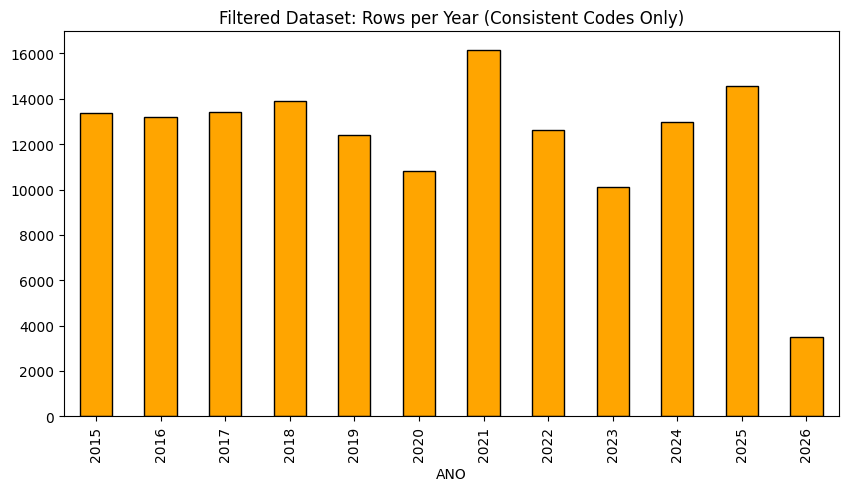

New yearly counts:
 ANO
2015    13362
2016    13215
2017    13430
2018    13919
2019    12428
2020    10808
2021    16161
2022    12631
2023    10113
2024    12969
2025    14582
2026     3494
Name: count, dtype: int64


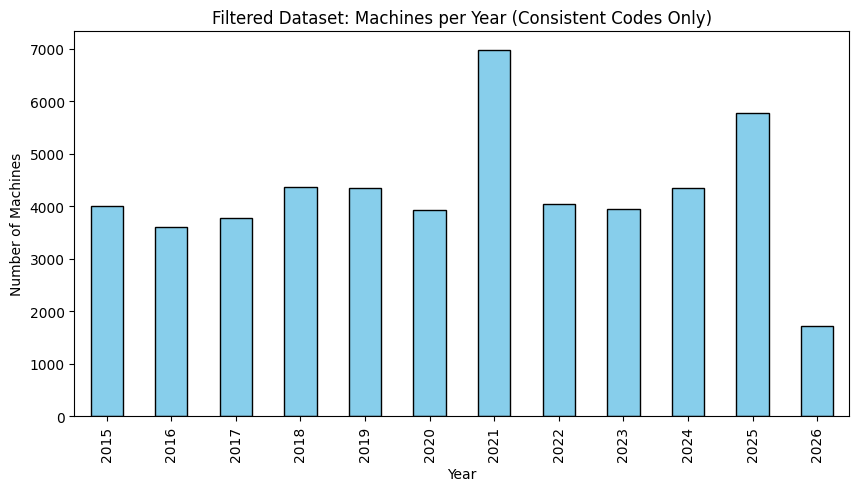

New yearly machine counts:
 ANO
2015    4014
2016    3610
2017    3778
2018    4374
2019    4350
2020    3935
2021    6984
2022    4046
2023    3953
2024    4354
2025    5787
2026    1728
Name: count, dtype: int64


In [68]:
# 1. Define the 12 HS Codes. Ler's remember I chose these codes since these are the ones CP TRUCKS deals with.
# We calculate it dynamically to be safe
codes_old = set(huge_dataset_final[huge_dataset_final['ANO'].astype(int) <= 2020]['PARTIDA_CLEAN'].unique())
codes_new = set(huge_dataset_final[huge_dataset_final['ANO'].astype(int) >= 2021]['PARTIDA_CLEAN'].unique())
common_codes = list(codes_old.intersection(codes_new))

print(f"Filtering dataset to keep only the {len(common_codes)} consistent HS codes...")

# 2. Apply the filter
df_final_clean = huge_dataset_final[huge_dataset_final['PARTIDA_CLEAN'].isin(common_codes)].copy()

# 3. Final Sanity Check: Let's see the new distribution
yearly_stats_clean = df_final_clean['ANO'].value_counts().sort_index()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
yearly_stats_clean.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Filtered Dataset: Rows per Year (Consistent Codes Only)')
plt.show()

print("New yearly counts:\n", yearly_stats_clean)

# 4. Yearly plot for 'IS_MACHINE' in the filtered dataset
yearly_stats_machines = df_final_clean[df_final_clean['IS_MACHINE'] == True]['ANO'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_stats_machines.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Filtered Dataset: Machines per Year (Consistent Codes Only)')
plt.ylabel('Number of Machines')
plt.xlabel('Year')
plt.show()

print("New yearly machine counts:\n", yearly_stats_machines)

# 5. Save this as your file for the thesis
df_final_clean.to_pickle("FINAL_CLEAN_DATASET_2015_2026.pkl")